In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import time

In [26]:
# Load Data
def load_and_split_data():
    # Reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    # CIFAR-10 Class Names
    CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck']
    (x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

    x_train = x_train_full[:40000].astype('float32')
    y_train = y_train_full[:40000]

    x_val = x_train_full[40000:].astype('float32')
    y_val = y_train_full[40000:]

    x_test = x_test.astype('float32')

    return x_train, y_train, x_val, y_val, x_test, y_test

In [27]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None, aug=False):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0) if not aug else model.fit(x_tr,
        validation_data=(x_v, to_categorical(y_v,10)),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb, verbose=0
    )

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

In [28]:
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [29]:
def BaselineCNN():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32,(3,3), activation= "relu", padding= "same"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,(3,3), activation= "relu", padding= "same"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation= "relu"),
        layers.Dense(10, activation= "softmax")
    ])
    return model

In [30]:
def build_model(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        layers.Conv2D(f1, (3,3), activation='relu', padding='same'),
        layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(f3, (3,3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

medium_model = build_model(32, 32, 64, 64)

In [31]:
x_train, y_train, x_val, y_val, x_test, y_test = load_and_split_data()

# Standardization
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))

x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

# 4A. Same Learning Rate

In [32]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
}

## Train with all 5 optimizers at

In [33]:
opt_results = {}
for opt_name, optimizer in optimizers.items():
    print(f"\n{'='*50}")
    print(f"  Training with optimizer: {opt_name}")
    print(f"{'='*50}\n")

    model = build_model(32, 32, 64, 64)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=30
    )

    opt_results[opt_name] = history



  Training with optimizer: SGD

Test Acc: 0.5290 | Test Loss: 1.3283 | Time:112.4s

  Training with optimizer: Momentum

Test Acc: 0.6502 | Test Loss: 1.3750 | Time:115.8s

  Training with optimizer: AdaGrad

Test Acc: 0.5710 | Test Loss: 1.2159 | Time:115.6s

  Training with optimizer: RMSProp

Test Acc: 0.7283 | Test Loss: 3.1788 | Time:115.5s

  Training with optimizer: Adam

Test Acc: 0.7101 | Test Loss: 2.5848 | Time:114.4s


In [57]:
print("{:<10} {:<20} {:<20} {:<20} {:<20}".format("Optimizer", "Train Loss", "Val Loss", "Test Acc", "Time"))
for opt_name, (history, test_acc, test_loss, elapsed) in opt_results.items():
    print("{:<10} {:<20} {:<20} {:<20} {:<20}".format(opt_name, f"{history.history['loss'][-1]:.4f}", f"{history.history['val_loss'][-1]:.4f}", f"{test_acc:.4f}", f"{elapsed:.1f}s"))

Optimizer  Train Loss           Val Loss             Test Acc             Time                
SGD        1.2878               1.3344               0.5290               112.4s              
Momentum   0.3288               1.3333               0.6502               115.8s              
AdaGrad    1.1377               1.2216               0.5710               115.6s              
RMSProp    0.0367               3.0759               0.7283               115.5s              
Adam       0.0391               2.4562               0.7101               114.4s              


## Plot: all 5 val accuracy curves on one graph

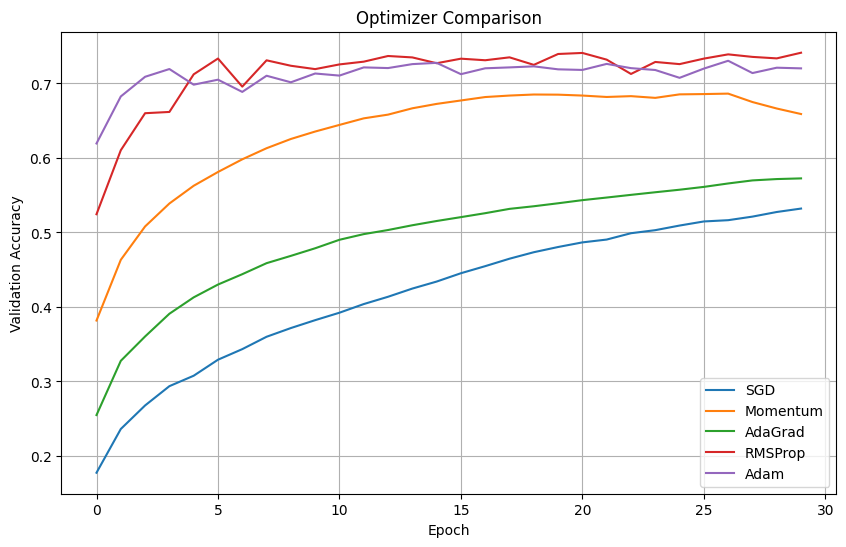

In [54]:
plot_curves([h for h, _, _, _ in opt_results.values()], list(opt_results.keys()), title="Optimizer Comparison", ylabel="Validation Accuracy")

## Plot: all 5 training loss curves on one graph

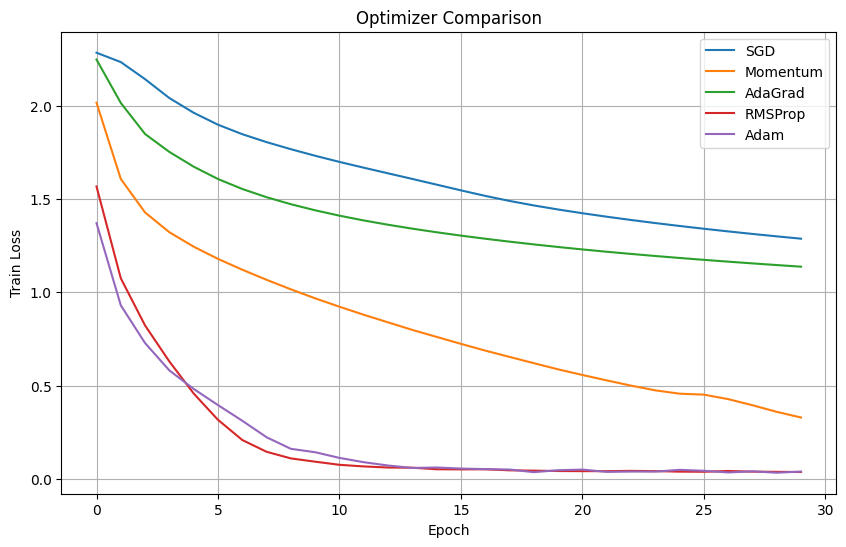

In [55]:
plot_curves([h for h, _, _, _ in opt_results.values()], list(opt_results.keys()), title="Optimizer Comparison", ylabel="Train Loss", metric='loss')

## **RMSProp converges fastest**

# 4B. Learning Rate Sensitivity — Adam

## Train with different learning rates

In [56]:
LRs = [0.0001, 0.001, 0.01]
lr_results = {}
for lr in LRs:
    print(f"\n{'='*50}")
    print(f"  Training with learning rate: {lr}")
    print(f"{'='*50}\n")

    model = build_model(32, 32, 64, 64)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=30
    )

    lr_results[lr] = history



  Training with learning rate: 0.0001

Test Acc: 0.6576 | Test Loss: 1.3823 | Time:126.0s

  Training with learning rate: 0.001

Test Acc: 0.7153 | Test Loss: 2.4942 | Time:116.4s

  Training with learning rate: 0.01

Test Acc: 0.1000 | Test Loss: 2.3032 | Time:111.8s


In [59]:
print("{:<10} {:<20} {:<20} {:<20}".format("LR", "Train Loss", "Val Loss", "Test Acc"))
for lr, (history, test_acc, test_loss, elapsed) in lr_results.items():
    print("{:<10} {:<20} {:<20} {:<20}".format(lr, f"{history.history['loss'][-1]:.4f}", f"{history.history['val_loss'][-1]:.4f}", f"{test_acc:.4f}", f"{elapsed:.1f}s"))

LR         Train Loss           Val Loss             Test Acc            
0.0001     0.2451               1.3531               0.6576              
0.001      0.0369               2.3919               0.7153              
0.01       2.3034               2.3035               0.1000              


## Plot: all 3 training loss curves on one graph

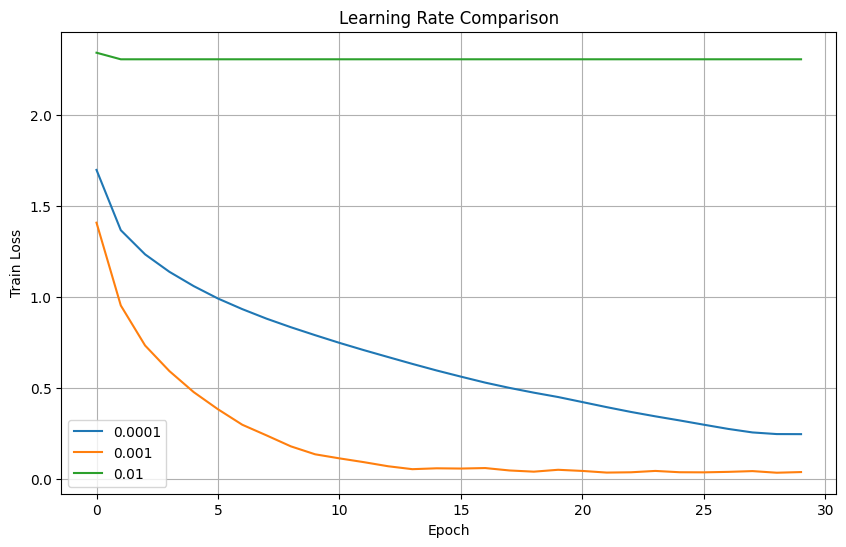

In [60]:
plot_curves([h for h, _, _, _ in lr_results.values()], list(lr_results.keys()), title="Learning Rate Comparison", ylabel="Train Loss", metric='loss')

## Plot: all 3 val accuracy curves on one graph

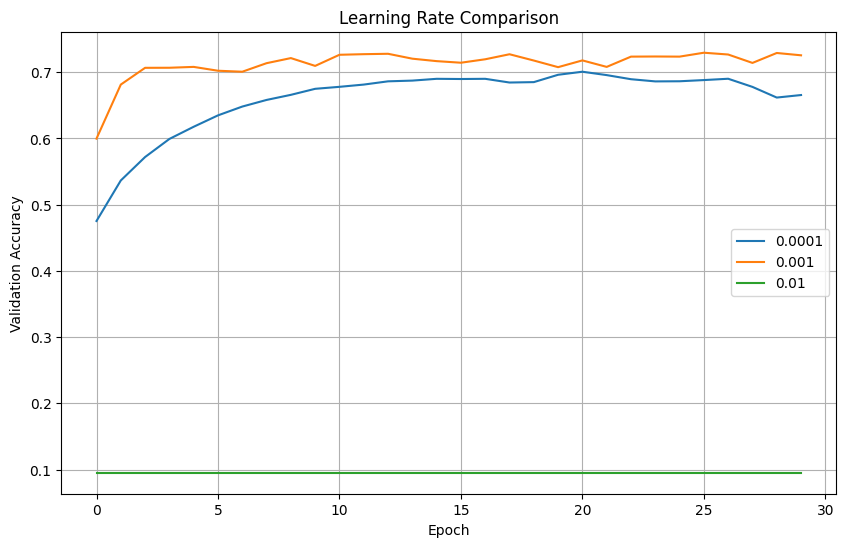

In [61]:
plot_curves([h for h, _, _, _ in lr_results.values()], list(lr_results.keys()), title="Learning Rate Comparison", ylabel="Validation Accuracy")

## Which learning rate is too slow? Which is unstable? Which is the best?

| Slow | Unstable | Best |
|---|---|---|
| 0.0001 | 0.01 | 0.001 |